In [63]:
!pip install kaggle

In [64]:
kaggle = '/content/kaggle.json'

In [65]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [66]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [67]:
from zipfile import ZipFile
import os
file_name ='handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [68]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [69]:
len(data_0)

2236

In [70]:
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [71]:
dataset_path = "/content/dataset"

X = []
y = []

for label in range(10):
    folder_path = os.path.join(dataset_path, str(label))
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # resize agar konsisten (28x28)
        img = cv2.resize(img, (28, 28))

        X.append(img)
        y.append(label)

In [72]:
X = np.array(X)
y = np.array(y)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (21555, 28, 28)
Shape y: (21555,)


In [73]:
X = X.reshape(X.shape[0], 28 * 28)

In [74]:
X = X / 255.0

In [75]:
y = to_categorical(y, 10)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (17244, 784)
X_test: (4311, 784)


In [77]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1102 - loss: 2.3336 - val_accuracy: 0.1870 - val_loss: 2.2370
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1956 - loss: 2.2187 - val_accuracy: 0.2389 - val_loss: 2.1305
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2540 - loss: 2.1090 - val_accuracy: 0.2363 - val_loss: 2.0638
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2868 - loss: 2.0287 - val_accuracy: 0.3674 - val_loss: 1.9124
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3625 - loss: 1.9001 - val_accuracy: 0.3578 - val_loss: 1.8325
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3983 - loss: 1.8097 - val_accuracy: 0.4549 - val_loss: 1.7402
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4222 - loss: 1.7605 - val_accuracy: 0.4590 - val_loss: 1.7377
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4422 - loss: 1.7157 - val_accuracy: 0

In [80]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4603 - loss: 1.6790
Test Loss: 1.666067123413086
Test Accuracy: 0.46207377314567566


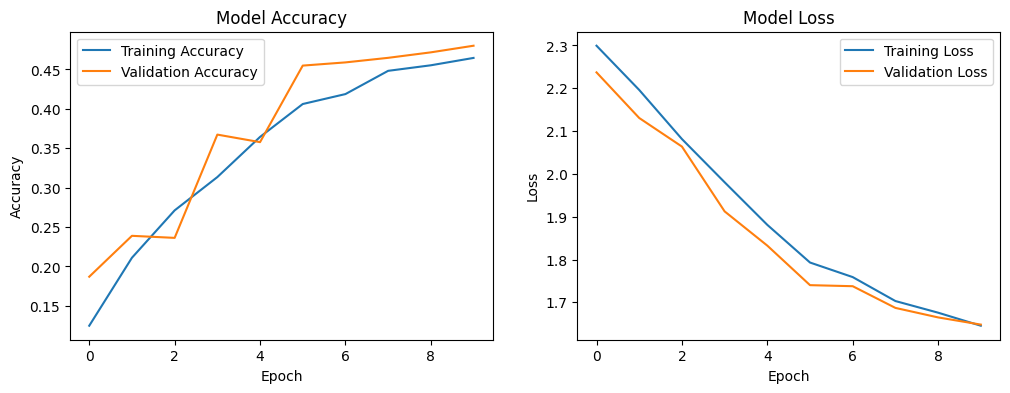

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()


In [85]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4603 - loss: 1.6790
Test Accuracy: 0.46207377314567566


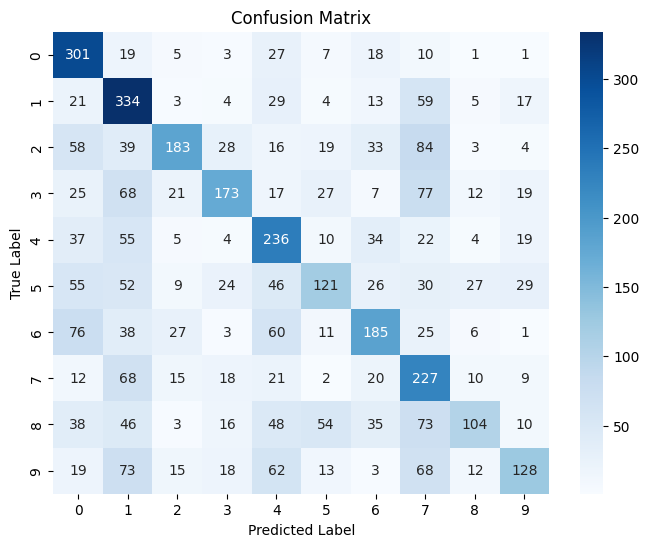

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.47      0.77      0.58       392
           1       0.42      0.68      0.52       489
           2       0.64      0.39      0.49       467
           3       0.59      0.39      0.47       446
           4       0.42      0.55      0.48       426
           5       0.45      0.29      0.35       419
           6       0.49      0.43      0.46       432
           7       0.34      0.56      0.42       402
           8       0.57      0.24      0.34       427
           9       0.54      0.31      0.40       411

    accuracy                           0.46      4311
   macro avg       0.49      0.46      0.45      4311
weighted avg       0.50      0.46      0.45      4311

